In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax 
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick
from flax import nnx


ball_stick = Ball2Stick.from_theta(np.random.randn(Ball2Stick.theta_dim))

In [3]:

@jax.jit
def simulator(rng):
    rng0, rng1, rng2, rng3, rng4 = jax.random.split(rng, 5)
    bvals = jax.random.choice(rng0, jnp.array(list(range(0, 2100, 100))), shape=(100,))
    bvals = jnp.sort(bvals)
    bvecs = jax.random.normal(rng3, shape=(100, 3))
    bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)
    theta = jax.random.normal(rng1, shape=(Ball2Stick.theta_dim,))
    model_mask = jax.random.bernoulli(rng2, p=0.6, shape=(3,))
    #model_mask = jnp.array([True, True, True])
    ball_stick = Ball2Stick.from_theta(theta, model_mask=model_mask)
    
    x_o = ball_stick.signal(bvals, bvecs)
    x_o = x_o + jax.random.normal(rng4, shape=x_o.shape) * 0.01
    return model_mask, theta, x_o, bvals, bvecs
    
    

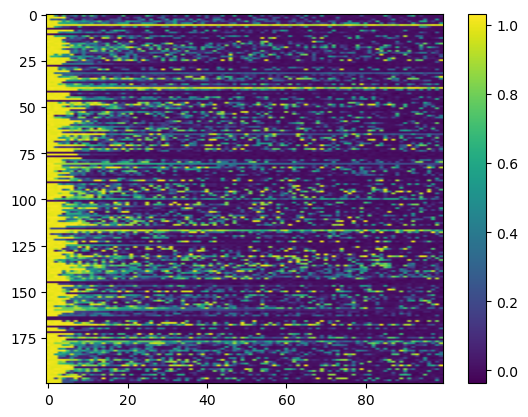

In [4]:
masks, theta, x_o, bvals, bvecs = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

plt.imshow(x_o, aspect='auto')
plt.colorbar()

In [5]:
from dmri.nn.dmri_reconstruction_model import DMRIInferenceModel, DMRIInferenceModelConfig
    
cfg = DMRIInferenceModelConfig(Ball2Stick)

model = DMRIInferenceModel(cfg, nnx.Rngs(0))

params_encoder = nnx.state(model.encoder)
params_model_decoder = nnx.state(model.model_decoder)
params_inference_decoder = nnx.state(model.inference_decoder)

params = (params_encoder, params_model_decoder, params_inference_decoder)


In [6]:
import optax


optimizer = optax.chain(optax.adaptive_grad_clip(50.), optax.adamw(5e-4))

opt_state = optimizer.init(params)


In [7]:

def loss_fn(params, data, rng):
    components, thetas,  xs, bvals, bvecs = data
    
    return model._loss(params[0], params[1], params[2], components, thetas, bvals, bvecs, xs, rng)


@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [8]:
batch_simulator = jax.jit(jax.vmap(simulator))

In [18]:
key = jax.random.PRNGKey(3)
for i in range(1):
    key, subkey1 = jax.random.split(key, 2) 
    masks, thetas, x_os, bvals, bevecs = batch_simulator(jax.random.split(subkey1, 2**16))
    l = 0
    for j in range(500):
        key, subkey2 = jax.random.split(key, 2) 
        idx = jax.random.randint(subkey2, (128,), 0, 2**16)
        masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch = masks[idx], thetas[idx], x_os[idx], bvals[idx], bevecs[idx]
        params, opt_state, loss = update(params, opt_state, (masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch), subkey2)
        l += loss
    print(l/500) 

KeyboardInterrupt: 

In [10]:
nnx.update(model.encoder, params[0])
nnx.update(model.model_decoder, params[1])
nnx.update(model.inference_decoder, params[2])

In [11]:
mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None))(jax.random.split(jax.random.key(0), 128), bvals[0], bevecs[0], x_os[0])

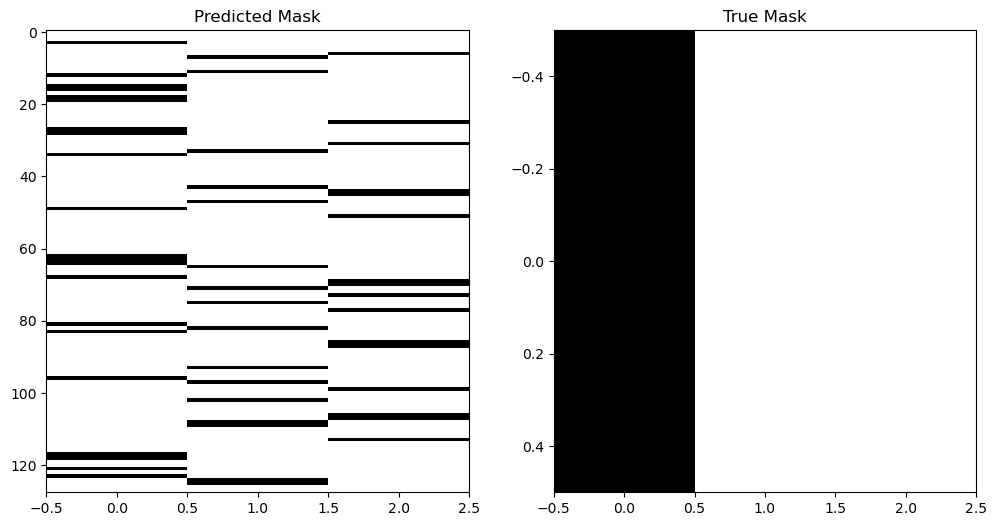

In [12]:
plt.figure(figsize=(12, 6))

# Plot predicted mask
plt.subplot(1, 2, 1)
plt.imshow(mask, aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('Predicted Mask')

# Plot true mask
mask_true = masks[0]
plt.subplot(1, 2, 2)
plt.imshow(mask_true[None], aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('True Mask')

plt.show()

In [17]:
thetas = jax.vmap(model.sample_theta, in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 1024), bvals[0], bevecs[0], x_os[0],masks[0])